In [ ]:
# Install required packages (run once)
!pip install networkx matplotlib numpy -q

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


# Graph Featurization

Raw graph structure alone is not always enough for machine learning. **Featurization** converts graph structure and node/edge properties into numeric vectors that models can consume.

## Why Featurization?

Graphs are inherently relational, but most ML models expect **fixed-size numeric inputs**. Featurization bridges this gap.

## Types of Graph Features
There are four main types:

| Type | What it captures | Examples |
|------|-----------------|----------|
| **1. Graph-level features** | Properties of the whole graph | Diameter, density, spectral features |
| **2. Edge features** | Properties of connections | Weight, transaction amount, timestamp |
| **3. Node features** | Properties of individual nodes | Age, degree, label |
| **Structural features** | Topological role of a node | Centrality, clustering coefficient, motif count |


> In Graph Neural Networks, the model learns to aggregate these features across multi-hop neighborhoods automatically.


### 1. Graph-Level Features (Global View)

Describe the **entire graph as a whole**.

### What they capture:
- Overall connectivity
- Global structure
- Network complexity

### Common Features:
- **Diameter** → longest shortest path in the graph  
- **Average path length** → average distance between nodes  
- **Density** → how many edges exist vs possible edges  
- **Modularity** → strength of community structure  

### Example:
- Social network: **High density** → many people are connected; **Low diameter** → information spreads quickly.
- Used in: Graph classification (e.g., molecule type, network type)


### 2. Edge-Level Features (Relationship View)

Describe **connections between two nodes**.

### What they capture:
- Strength or nature of relationships  
- Likelihood of future connections  

### Common Features:
- **Weight** → distance, cost, interaction frequency  
- **Common neighbors** → shared connections  
- **Jaccard similarity** → similarity between neighborhoods  
- **Edge betweenness** → importance of an edge  

### Example:
- E-commerce:
  - Edge = user → product  
  - Weight = number of purchases  
- Social network:
  - Two users with many common friends → high similarity  

Used in: Link prediction, Recommendation systems, Fraud detection.  


### 3. Node-Level Features (Local View — Focus)

Describe **individual nodes**. There are two ways - via "Degree" and via "Centrality"

#### (a) **Degree**:
Number of connections a node has  
**Types:**
- **In-degree** → incoming edges  
- **Out-degree** → outgoing edges  

### Example:
- Twitter:
  - High in-degree → many followers  
  - High out-degree → follows many people  

> **Interpretation**:High degree → more connected → potentially more influence  


#### (b) **Centrality** (Covered Next Section)

Centrality measures capture **node importance** in the network.

- **Degree Centrality**: Measures importance based on the number of direct connections a node has.  
- **Closeness Centrality**: Measures how quickly a node can reach all other nodes in the network.  
- **Betweenness Centrality**: Measures how often a node lies on the shortest paths between other nodes (bridge nodes).  
- **Eigenvector Centrality**: Measures importance by considering not just connections, but how important those neighbors are.


## 4. Structural Features (Topological Role)

Describe how a node is positioned in the **overall structure**.

### What they capture:
- Local neighborhood patterns  
- Role of node in graph structure  

### Common Features:
- **Clustering coefficient** → how connected neighbors are  
- **Triangle count** → number of triangles a node participates in  
- **Motifs** → recurring subgraph patterns  

### Example:
- Social network:High clustering → tight friend group  
- Fraud detection: Unusual patterns → suspicious behavior  




=== Node Feature Matrix (structural features) ===
         Degree  Clustering Coeff  Closeness Centrality  Betweenness Centrality  Avg Neighbor Degree
Node                                                                                                
You         2.0             1.000                 0.556                    0.00                 3.00
Alice       3.0             0.333                 0.714                    0.30                 2.67
Bob         3.0             0.000                 0.714                    0.45                 2.00
Charlie     3.0             0.333                 0.625                    0.15                 2.33
David       1.0             0.000                 0.455                    0.00                 3.00
Eve         2.0             0.000                 0.625                    0.10                 3.00


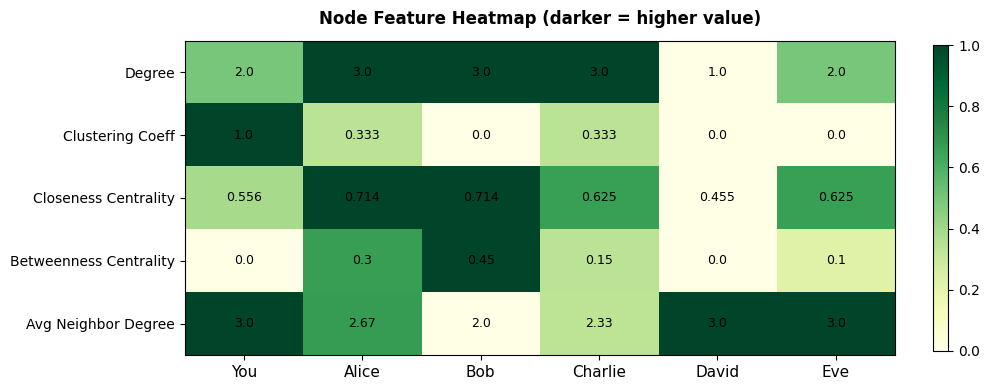

In [ ]:
# ── Build a feature table for each node ─────────────────────────────────────
features = {}
for node in G.nodes():
    deg   = G.degree(node)
    cc    = nx.clustering(G, node)
    close = nx.closeness_centrality(G, node)
    betw  = nx.betweenness_centrality(G)[node]
    neigh_degrees = [G.degree(nb) for nb in G.neighbors(node)]
    avg_nb_deg = np.mean(neigh_degrees) if neigh_degrees else 0

    features[node] = {
        'Degree':                      deg,
        'Clustering Coeff':            round(cc,   3),
        'Closeness Centrality':        round(close,3),
        'Betweenness Centrality':      round(betw, 3),
        'Avg Neighbor Degree':         round(avg_nb_deg, 2),
    }

df_features = pd.DataFrame(features).T
df_features.index.name = 'Node'
print("=== Node Feature Matrix (structural features) ===")
print(df_features.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
data_norm = df_features.apply(lambda col: (col - col.min()) / (col.max() - col.min() + 1e-9))
im = ax.imshow(data_norm.T.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(df_features)))
ax.set_yticks(range(len(df_features.columns)))
ax.set_xticklabels(df_features.index, fontsize=11)
ax.set_yticklabels(df_features.columns, fontsize=10)
for i, col in enumerate(df_features.columns):
    for j, node in enumerate(df_features.index):
        ax.text(j, i, df_features.loc[node, col], ha='center', va='center', fontsize=9)
ax.set_title('Node Feature Heatmap (darker = higher value)', fontsize=12, fontweight='bold', pad=12)
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()